# TTP Metaheuristics

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

from core.ttp_loader import load_instance
from core.ttp_evaluator import TTPEvaluator
from solvers.aco_solver import ACOSolver
from solvers.gwo_solver import GWOSolver
from solvers.ga_solver import GA
from solvers.ga_improved_solver import GAImproved
from solvers.sa_solver import SA
from solvers.sa_improved_solver import SAImproved
from solvers.s5_solver import S5Solver
from solvers.brute_force_solver import BruteForceSolver
from visuals.convergence import plot_convergence
from visuals.tour_map import plot_tour, plot_tour_with_weight_profit, trace_to_dataframe, results_summary
from visuals.animations import animate_weight_profit
import matplotlib.pyplot as plt
import pandas as pd

INSTANCES = {
    "tiny9": "benchmarks/tiny/tiny_n9_m8.ttp",
    "tiny7": "benchmarks/tiny/tiny_n7_m6.ttp",
    "tiny5": "benchmarks/tiny/tiny_n5_m4.ttp",
    "eil51_uncorr": "benchmarks/eil51/eil51_n50_uncorr_01.ttp",
    "eil51_corr":   "benchmarks/eil51/eil51_n50_bounded-strongly-corr_01.ttp",
}

SOLVERS = {
    "ACO":         lambda: ACOSolver(max_iterations=1000),
    "GWO":         lambda: GWOSolver(max_iterations=1000),
    "GA":          lambda: GA(max_iterations=1000),
    "GA_Improved": lambda: GAImproved(max_iterations=1000),
    "SA":          lambda: SA(),
    "SA_Improved": lambda: SAImproved(),
    "S5":          lambda: S5Solver(),
}

RUNS = 3
INSTANCE_NAME = "eil51_corr"  # change to switch instance
RUN_BRUTE_FORCE = False   # exhaustive search only safe on tiny 

os.makedirs("results", exist_ok=True)
all_results = {}
instance = load_instance(INSTANCES[INSTANCE_NAME])
print(f"Loaded: {INSTANCE_NAME}  ({instance.n} cities, {instance.m} items)")
print(f"Capacity={instance.capacity:.0f}  v_min={instance.v_min}  v_max={instance.v_max}  renting_rate={instance.renting_rate}")

Loaded: eil51_corr  (51 cities, 50 items)
Capacity=4029  v_min=0.1  v_max=1.0  renting_rate=4.44


## ACO

,score,runtime_s
run,,
1,3819.448240,13.592778
2,3603.749014,7.788506
3,3582.681620,8.837981


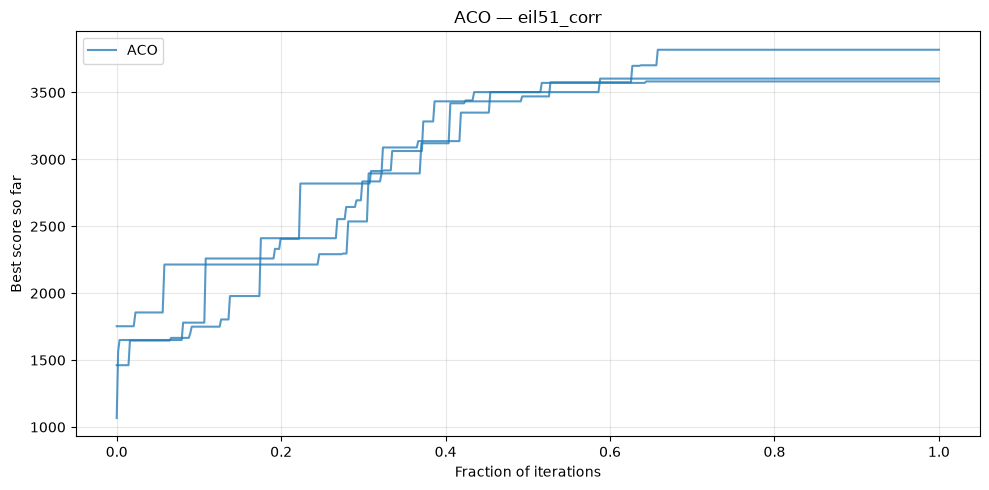

In [2]:
algo_name = "ACO"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

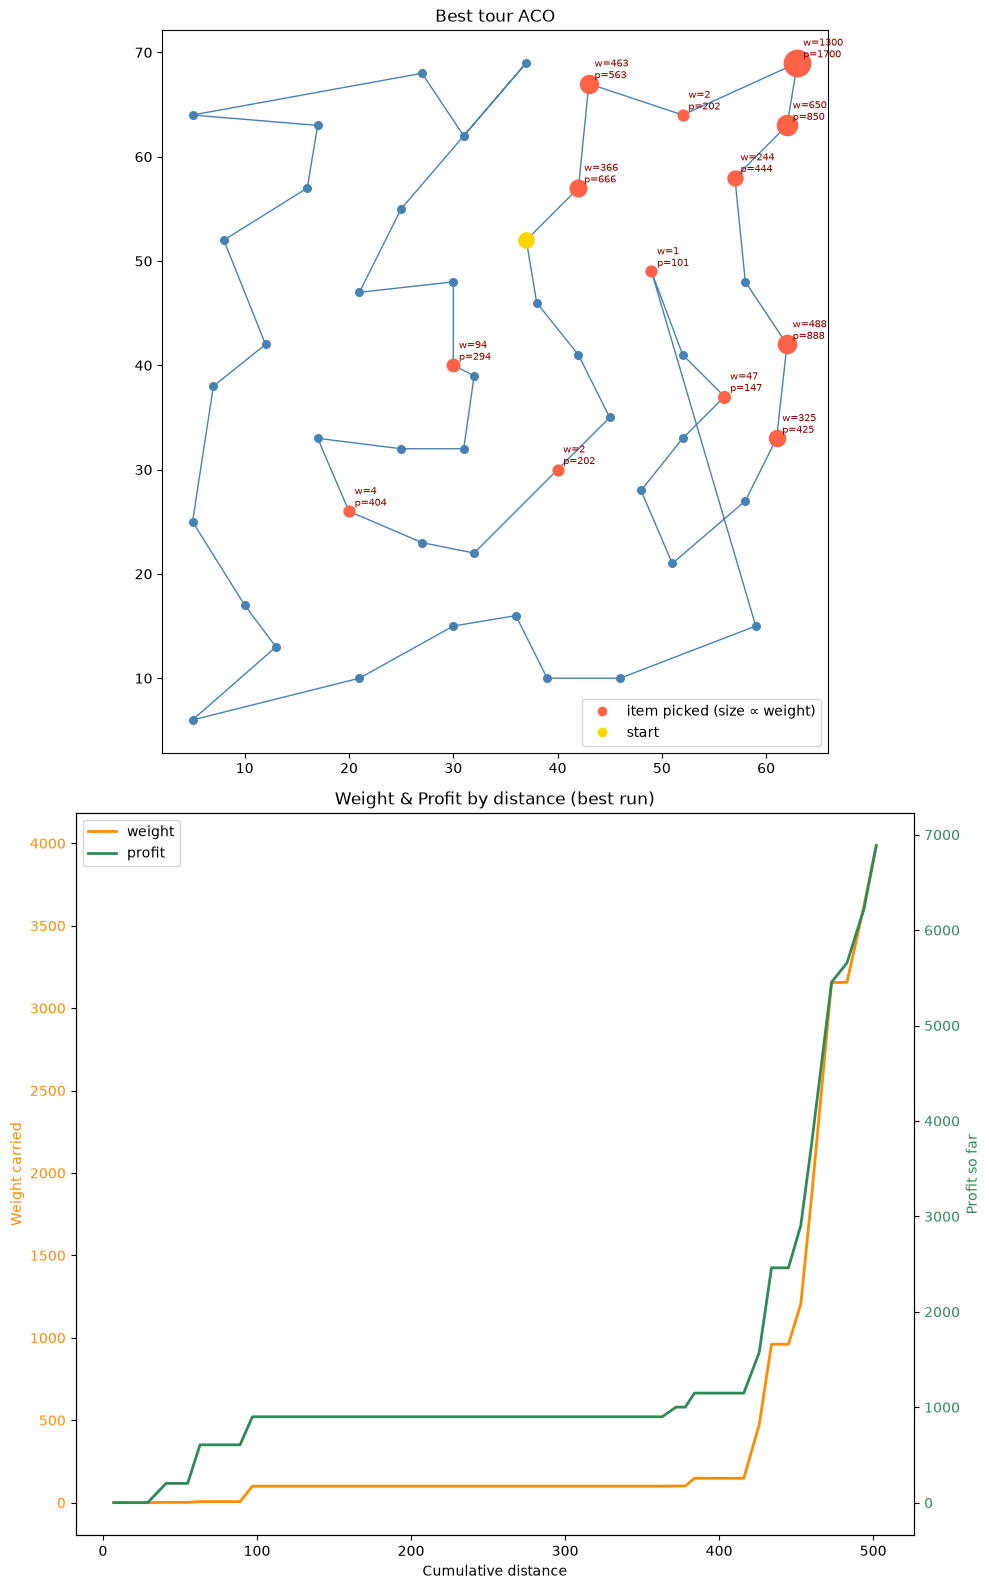

Animation saved to results/aco_weight_profit.gif


In [3]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [4]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,31,[],0.0,0.0,7,7.000000,-31.080000
1,31,10,[],0.0,0.0,7,7.000000,-62.160000
2,10,37,[],0.0,0.0,7,7.000000,-93.240000
3,37,4,[],0.0,0.0,8,8.000000,-128.760000
4,4,36,[3],2.0,202.0,12,12.005364,19.936186
5,36,16,[],2.0,202.0,6,6.002682,-6.715721
6,16,3,[],2.0,202.0,8,8.003576,-42.251597
7,3,17,[2],6.0,606.0,8,8.010737,326.180732
8,17,46,[],6.0,606.0,9,9.012079,286.167103


## GWO

,score,runtime_s
run,,
1,2640.536695,0.465738
2,2818.046856,0.910080
3,2867.723730,1.234206


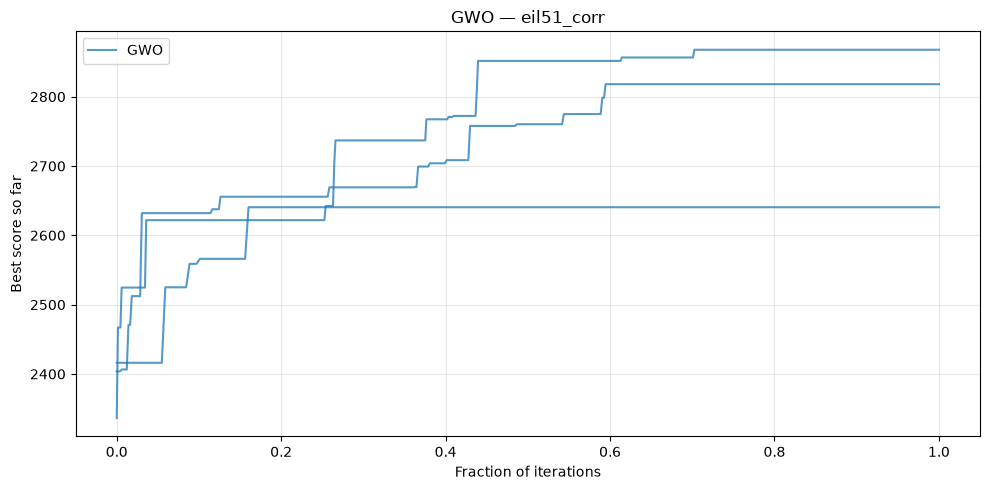

In [5]:
algo_name = "GWO"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

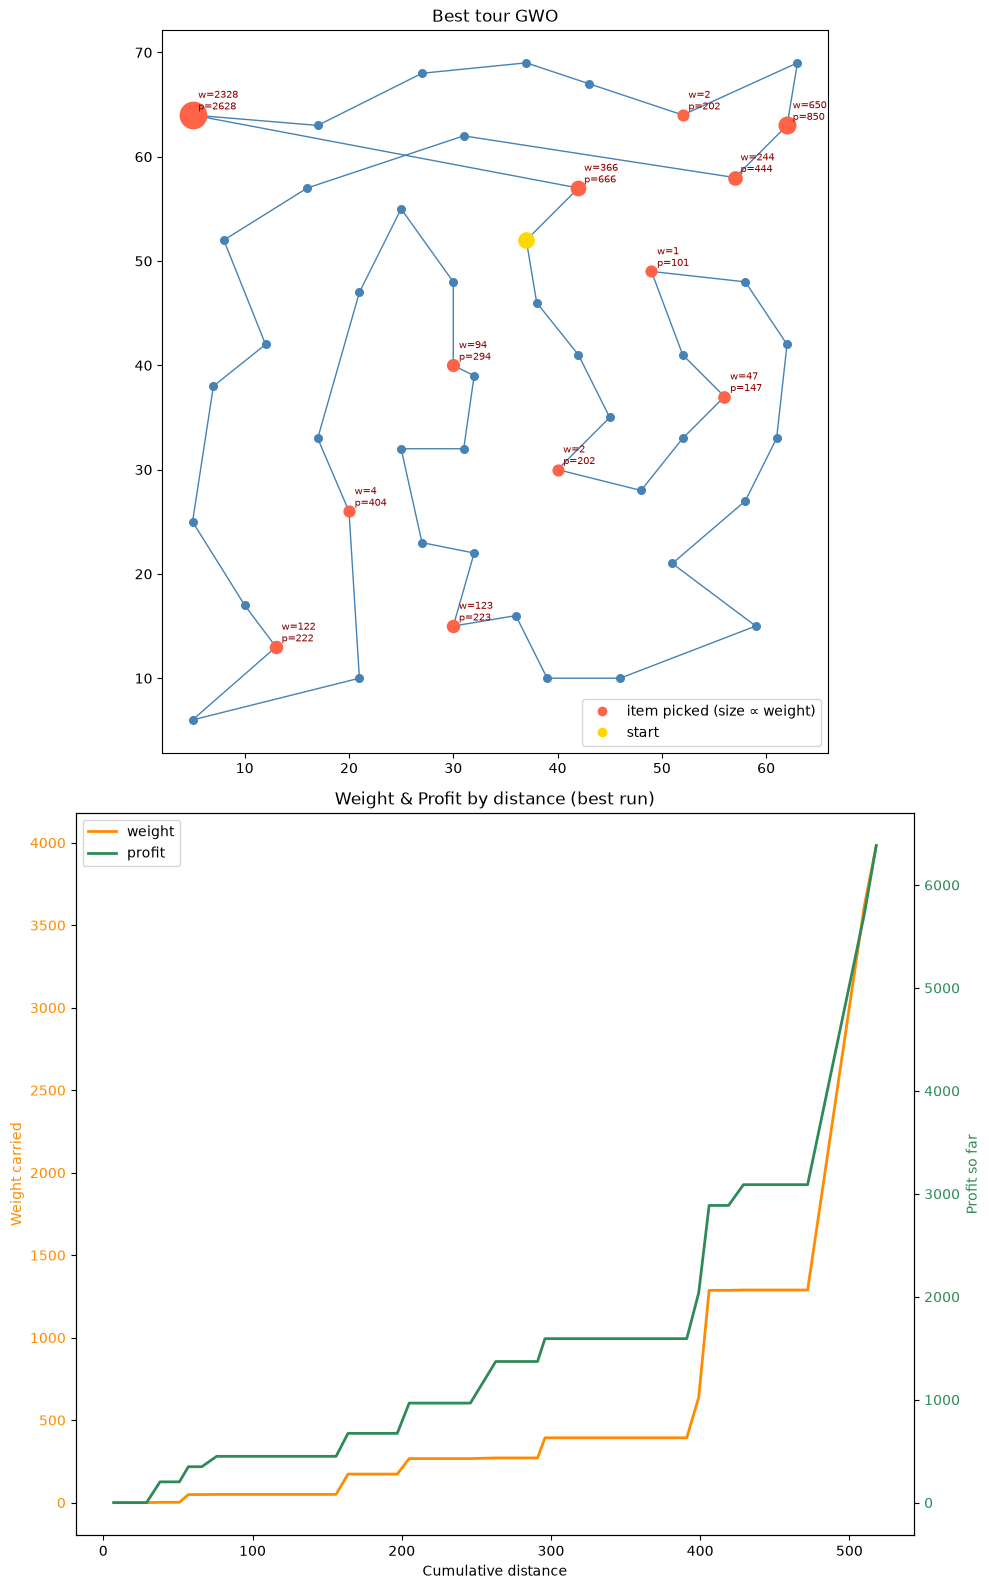

Animation saved to results/gwo_weight_profit.gif


In [6]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [7]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,31,[],0.0,0.0,7,7.000000,-31.080000
1,31,10,[],0.0,0.0,7,7.000000,-62.160000
2,10,37,[],0.0,0.0,7,7.000000,-93.240000
3,37,4,[],0.0,0.0,8,8.000000,-128.760000
4,4,48,[3],2.0,202.0,9,9.004023,33.262139
5,48,8,[],2.0,202.0,7,7.003129,2.168248
6,8,49,[],2.0,202.0,6,6.002682,-24.483659
7,49,15,[48],49.0,349.0,6,6.066401,95.581522
8,15,1,[],49.0,349.0,9,9.099601,55.179294


## GA

,score,runtime_s
run,,
1,2667.503891,0.476896
2,3377.678584,1.071935
3,2816.970812,0.572154


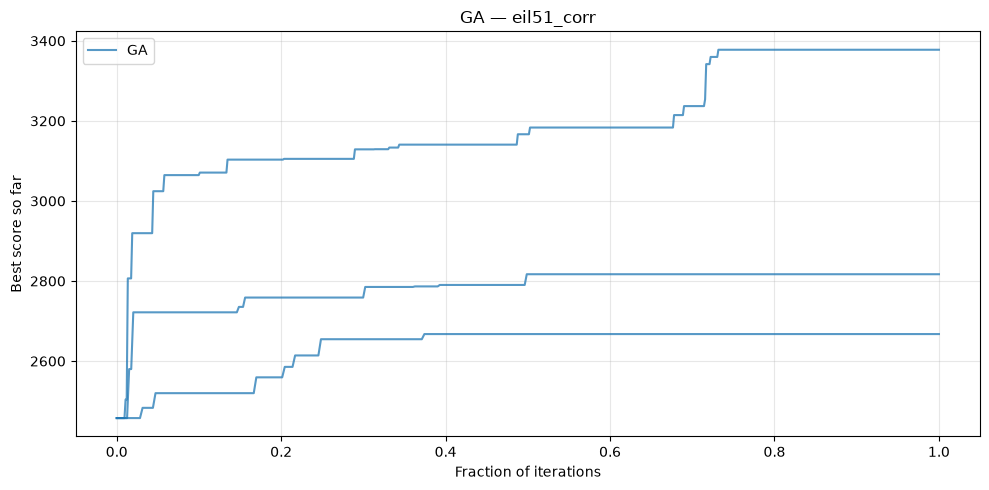

In [8]:
algo_name = "GA"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

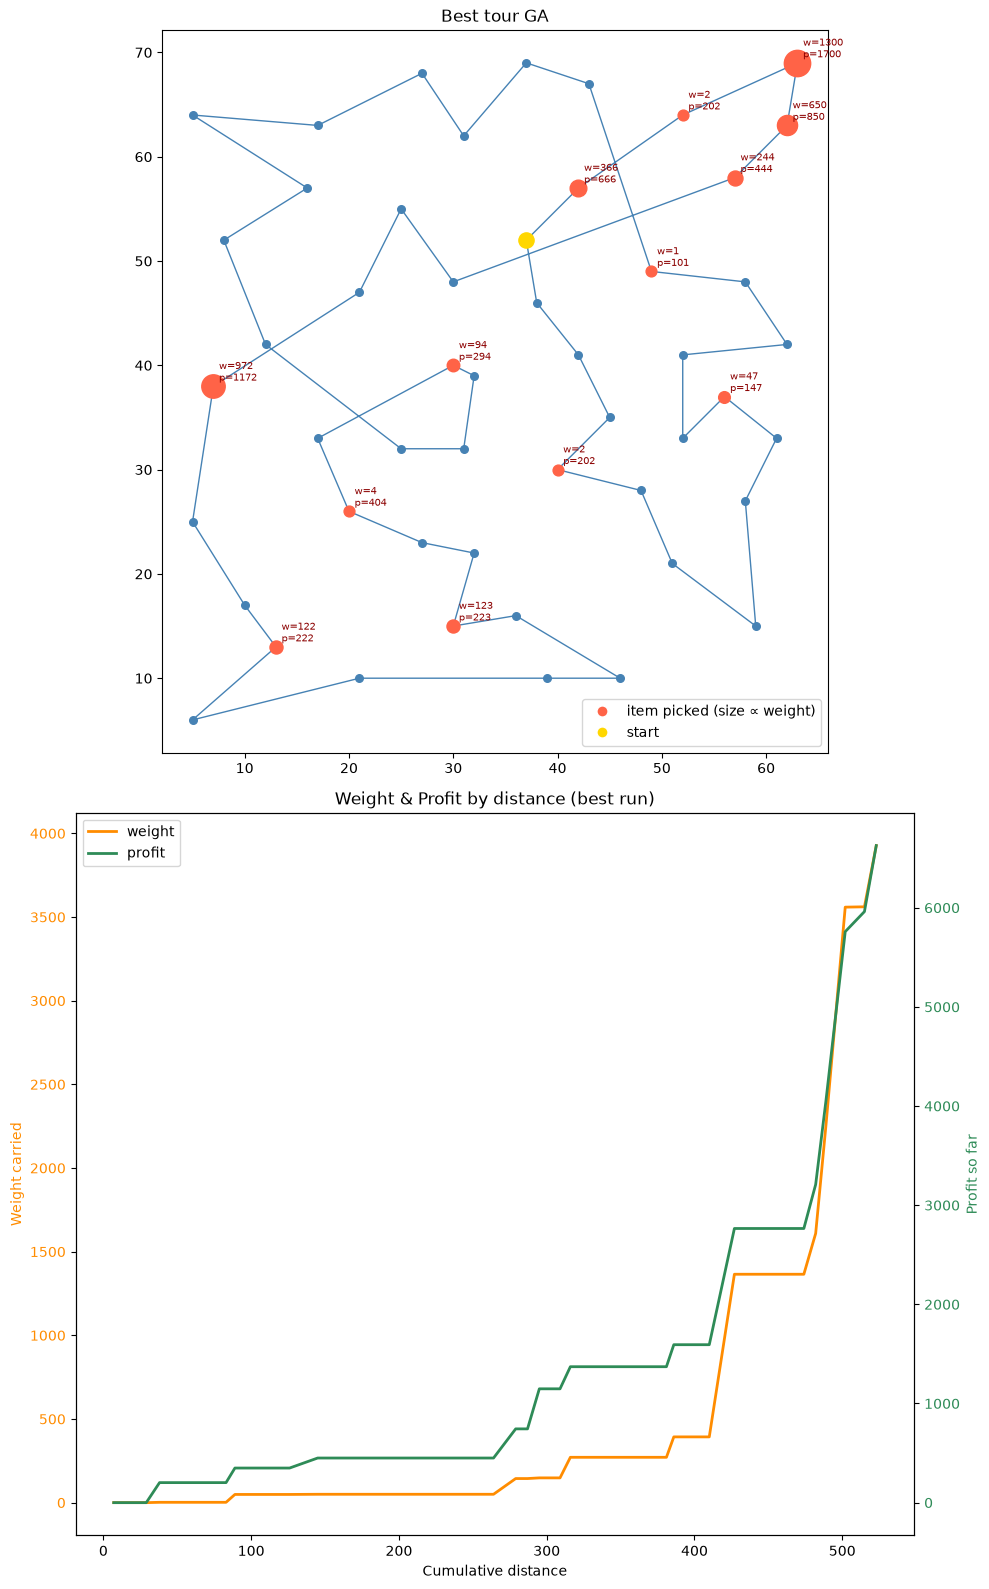

Animation saved to results/ga_weight_profit.gif


In [9]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [10]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,31,[],0.0,0.0,7,7.000000,-31.080000
1,31,10,[],0.0,0.0,7,7.000000,-62.160000
2,10,37,[],0.0,0.0,7,7.000000,-93.240000
3,37,4,[],0.0,0.0,8,8.000000,-128.760000
4,4,48,[3],2.0,202.0,9,9.004023,33.262139
5,48,9,[],2.0,202.0,8,8.003576,-2.273737
6,9,38,[],2.0,202.0,10,10.004470,-46.693582
7,38,29,[],2.0,202.0,13,13.005810,-104.439380
8,29,33,[],2.0,202.0,7,7.003129,-135.533272


## GA Improved

,score,runtime_s
run,,
1,3806.568528,59.042006
2,3951.150047,29.052125
3,4269.213352,36.261242


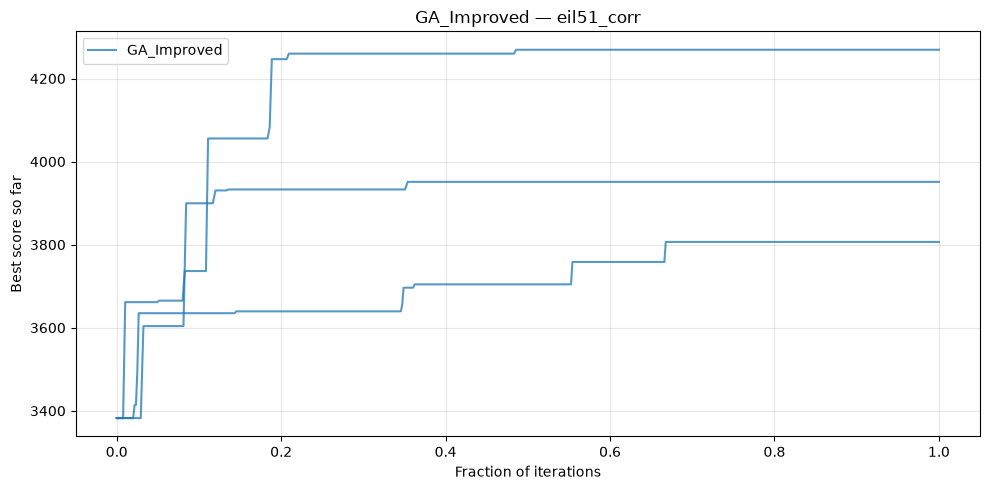

In [11]:
algo_name = "GA_Improved"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

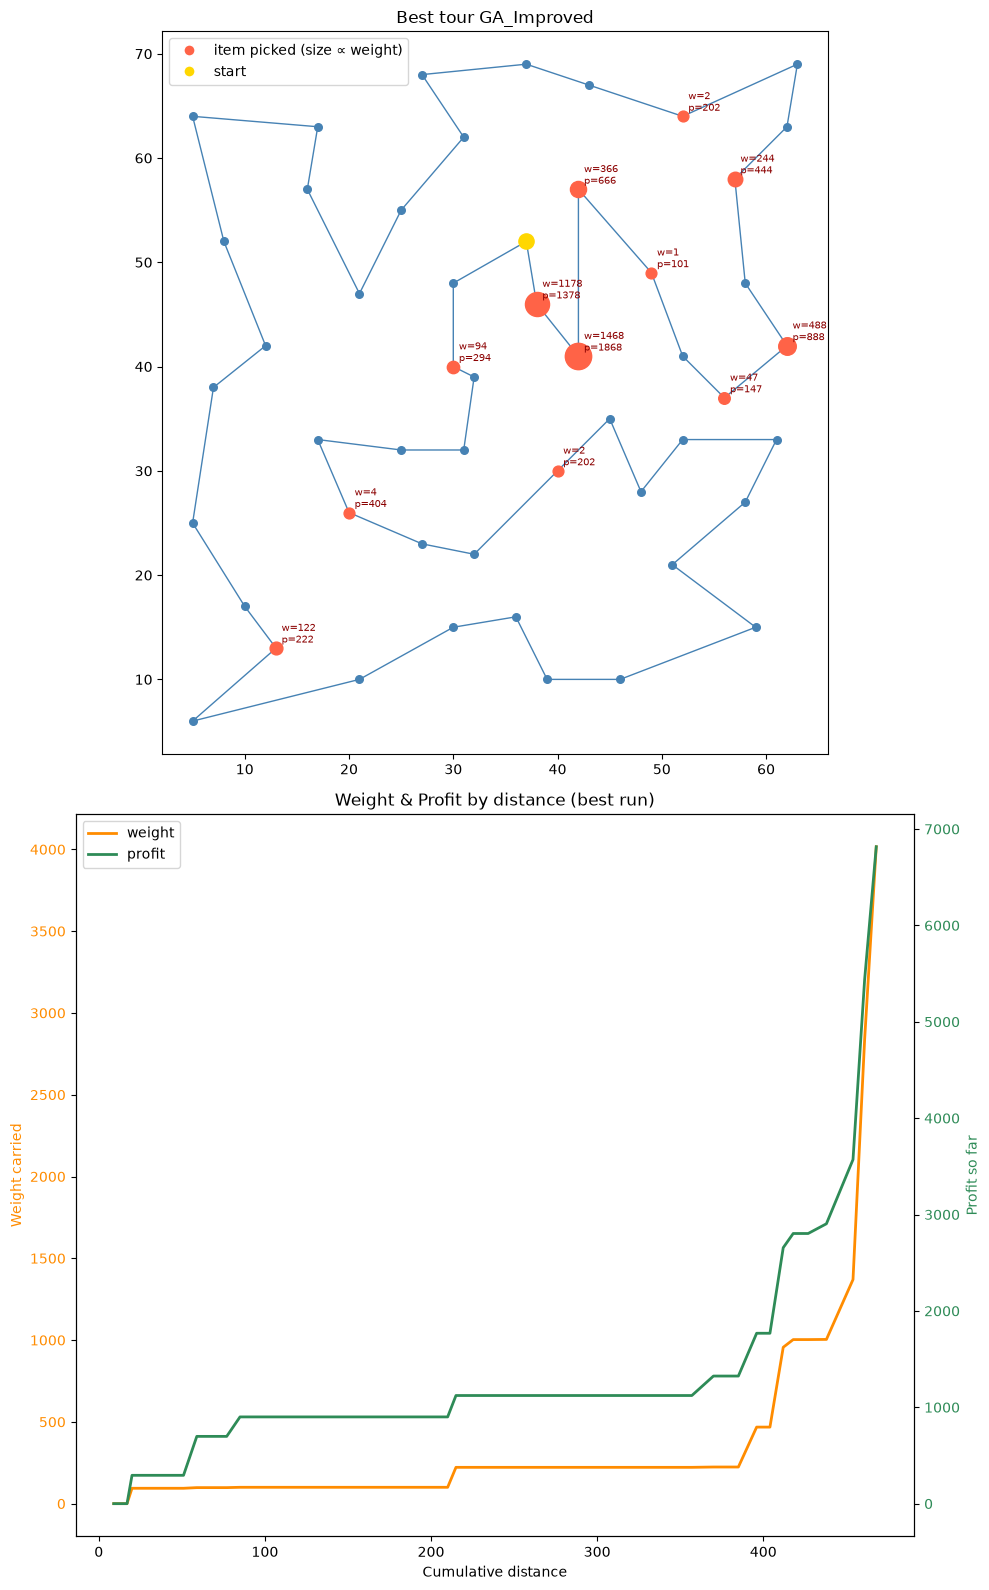

Animation saved to results/ga_improved_weight_profit.gif


In [12]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [13]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,26,[],0.0,0.0,9,9.000000,-39.960000
1,26,50,[],0.0,0.0,8,8.000000,-75.480000
2,50,45,[49],94.0,294.0,3,3.064344,204.914311
3,45,11,[],94.0,294.0,8,8.171585,168.632473
4,11,46,[],94.0,294.0,6,6.128689,141.421095
5,46,17,[],94.0,294.0,9,9.193033,100.604028
6,17,3,[],94.0,294.0,8,8.171585,64.322190
7,3,16,[2],98.0,698.0,8,8.179050,432.007209
8,16,36,[],98.0,698.0,6,6.134287,404.770972


## SA

,score,runtime_s
run,,
1,2797.775468,0.193623
2,2799.675936,0.189160
3,2939.510543,0.184141


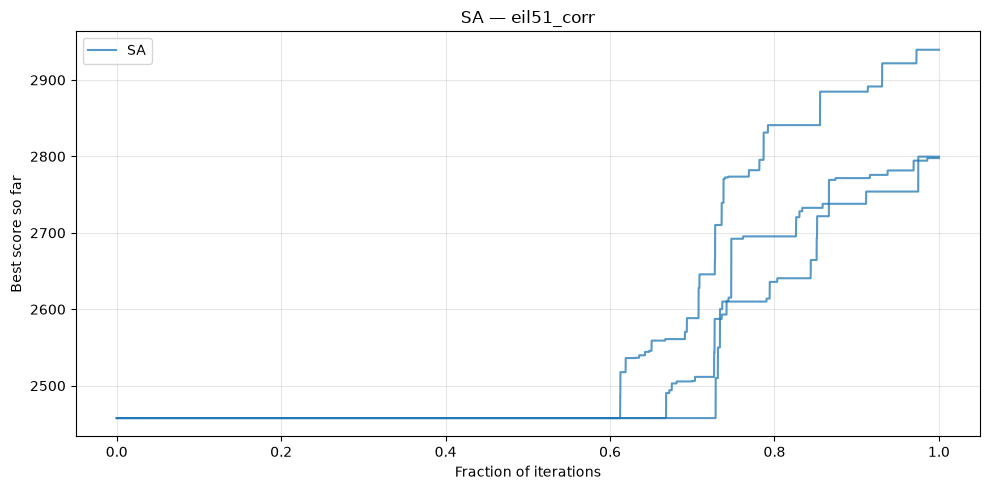

In [14]:
algo_name = "SA"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

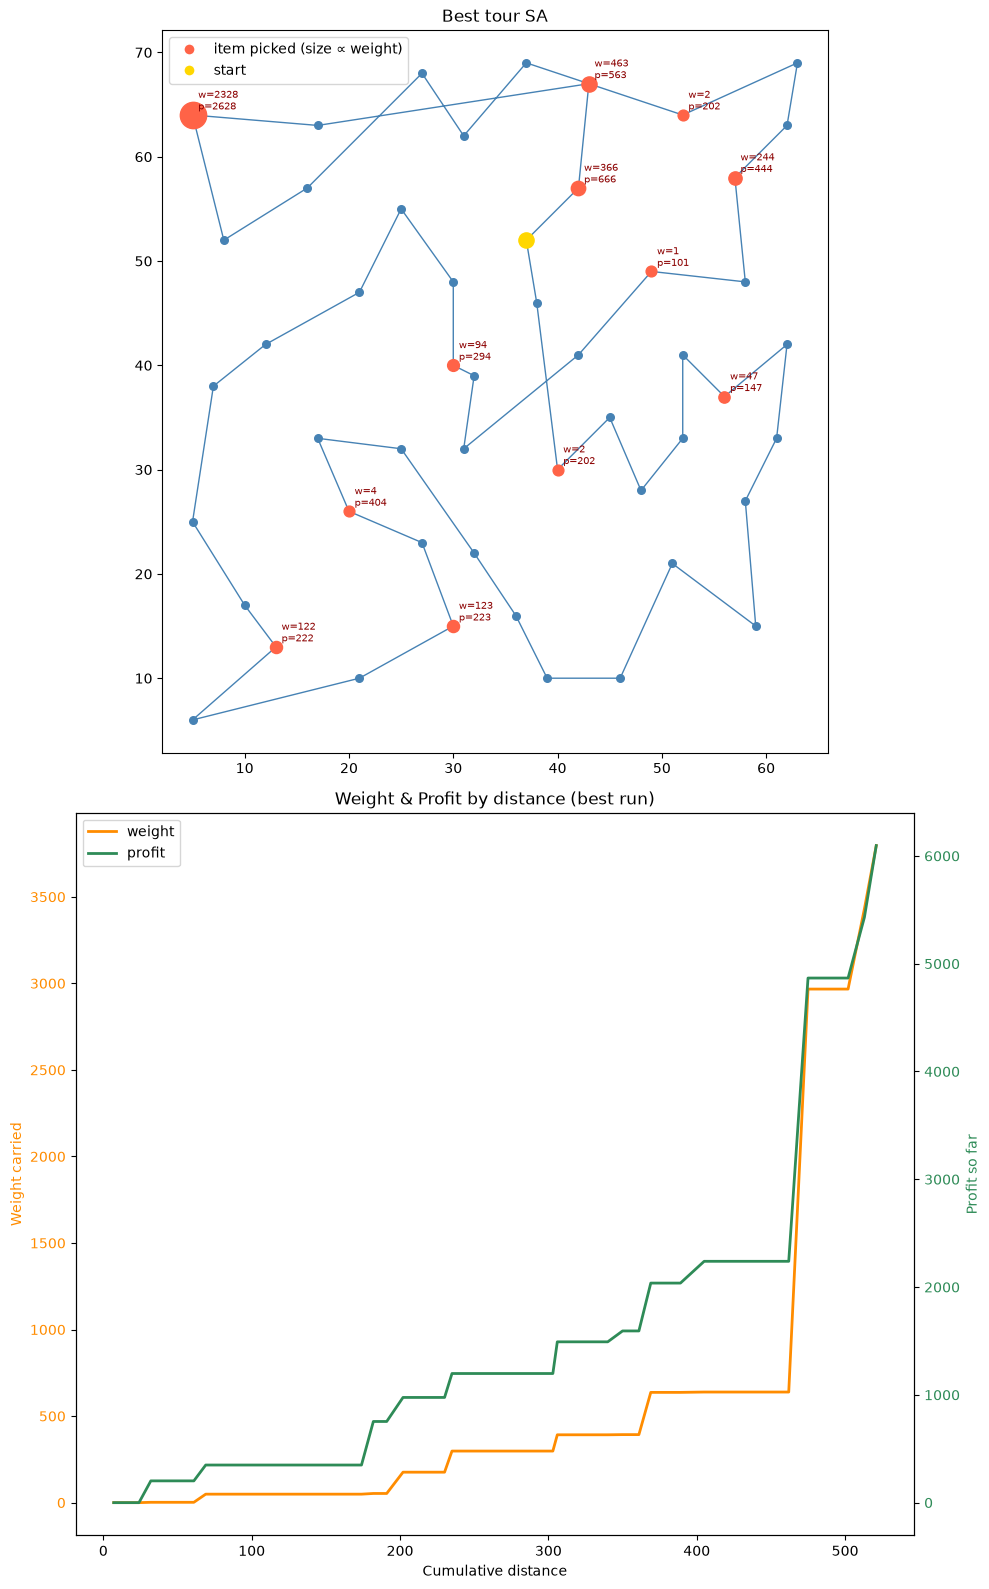

Animation saved to results/sa_weight_profit.gif


In [15]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [16]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,31,[],0.0,0.0,7,7.000000,-31.080000
1,31,4,[],0.0,0.0,17,17.000000,-106.560000
2,4,37,[3],2.0,202.0,8,8.003576,59.904124
3,37,48,[],2.0,202.0,8,8.003576,24.368248
4,48,8,[],2.0,202.0,7,7.003129,-6.725644
5,8,15,[],2.0,202.0,8,8.003576,-42.261520
6,15,49,[],2.0,202.0,6,6.002682,-68.913427
7,49,20,[48],49.0,349.0,8,8.088534,42.173481
8,20,33,[],49.0,349.0,10,10.110668,-2.717884


## SA Improved

,score,runtime_s
run,,
1,3911.549427,6.782798
2,3763.490796,6.923973
3,4000.398430,6.661018


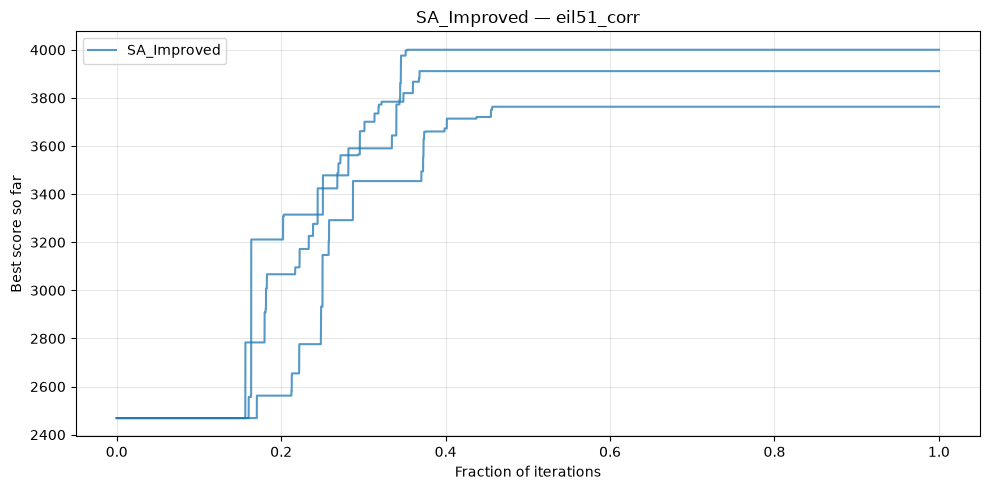

In [17]:
algo_name = "SA_Improved"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

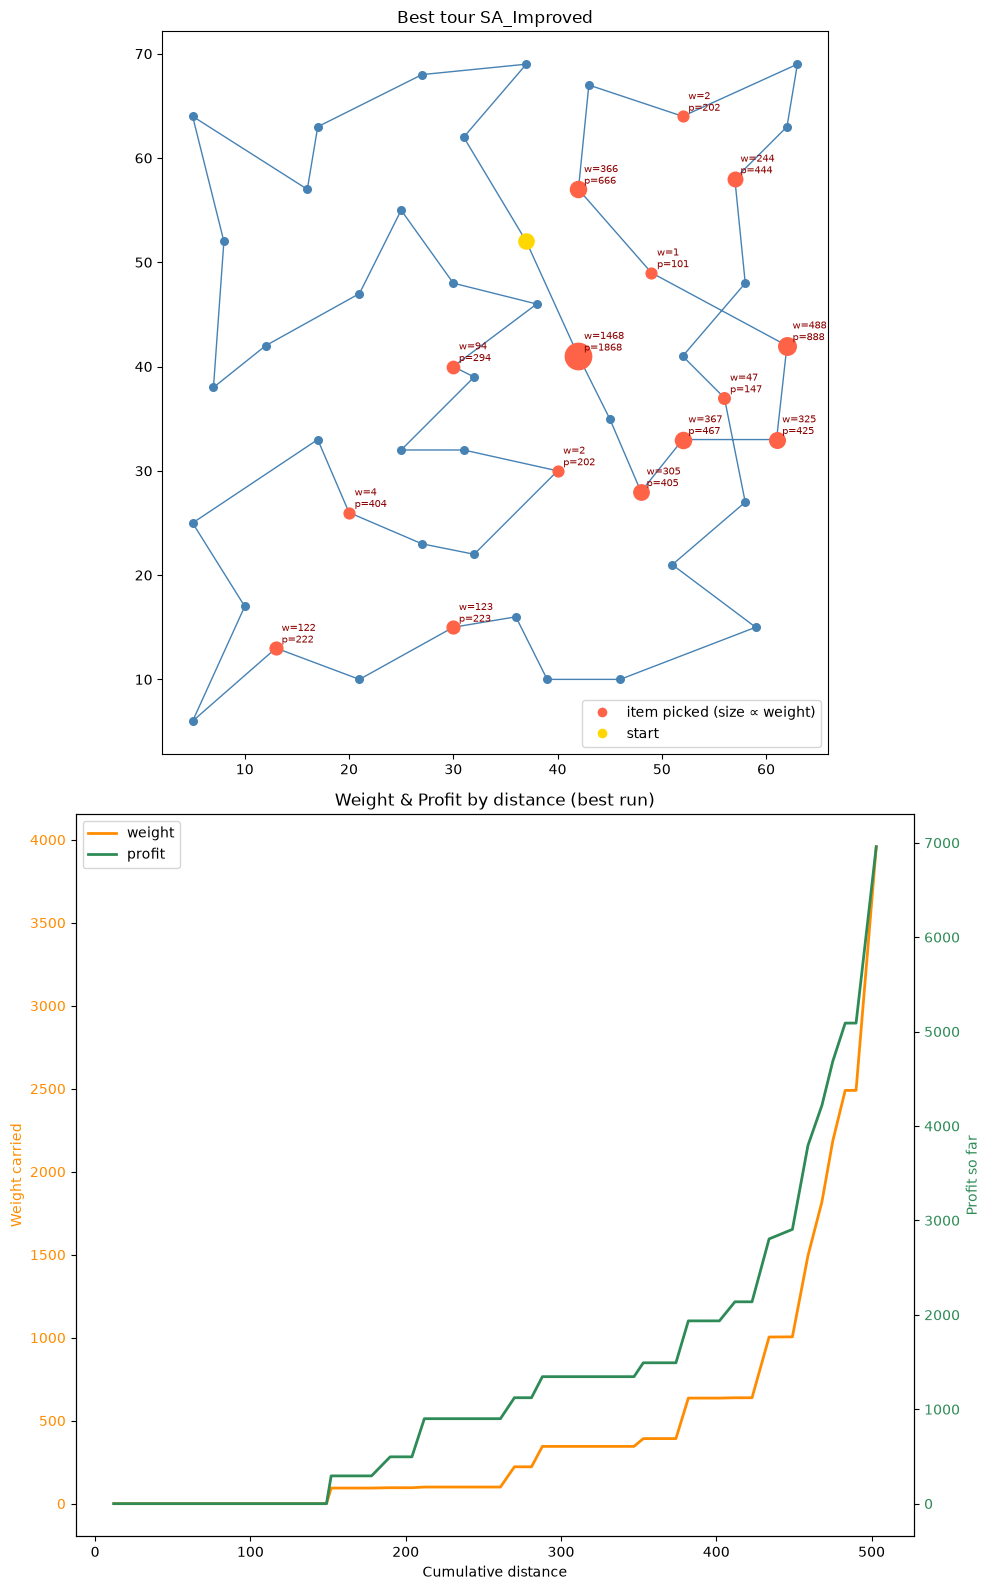

Animation saved to results/sa_improved_weight_profit.gif


In [18]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [19]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,7,[],0.0,0.0,12,12.000000,-53.280000
1,7,30,[],0.0,0.0,10,10.000000,-97.680000
2,30,25,[],0.0,0.0,11,11.000000,-146.520000
3,25,6,[],0.0,0.0,12,12.000000,-199.800000
4,6,22,[],0.0,0.0,7,7.000000,-230.880000
5,22,42,[],0.0,0.0,14,14.000000,-293.040000
6,42,23,[],0.0,0.0,13,13.000000,-350.760000
7,23,24,[],0.0,0.0,15,15.000000,-417.360000
8,24,13,[],0.0,0.0,7,7.000000,-448.440000


## S5

,score,runtime_s
run,,
1,2575.117343,0.000817
2,2575.117343,0.000799
3,2575.117343,0.000782


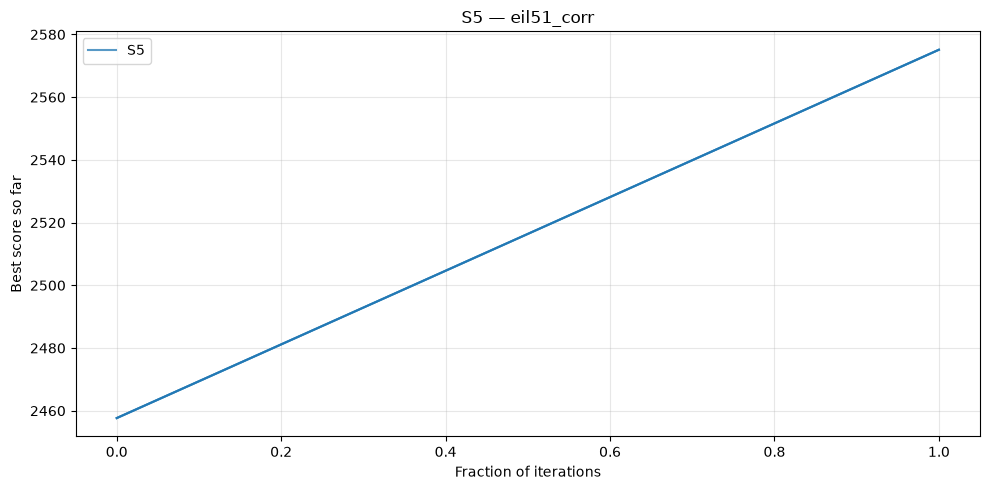

In [20]:
algo_name = "S5"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

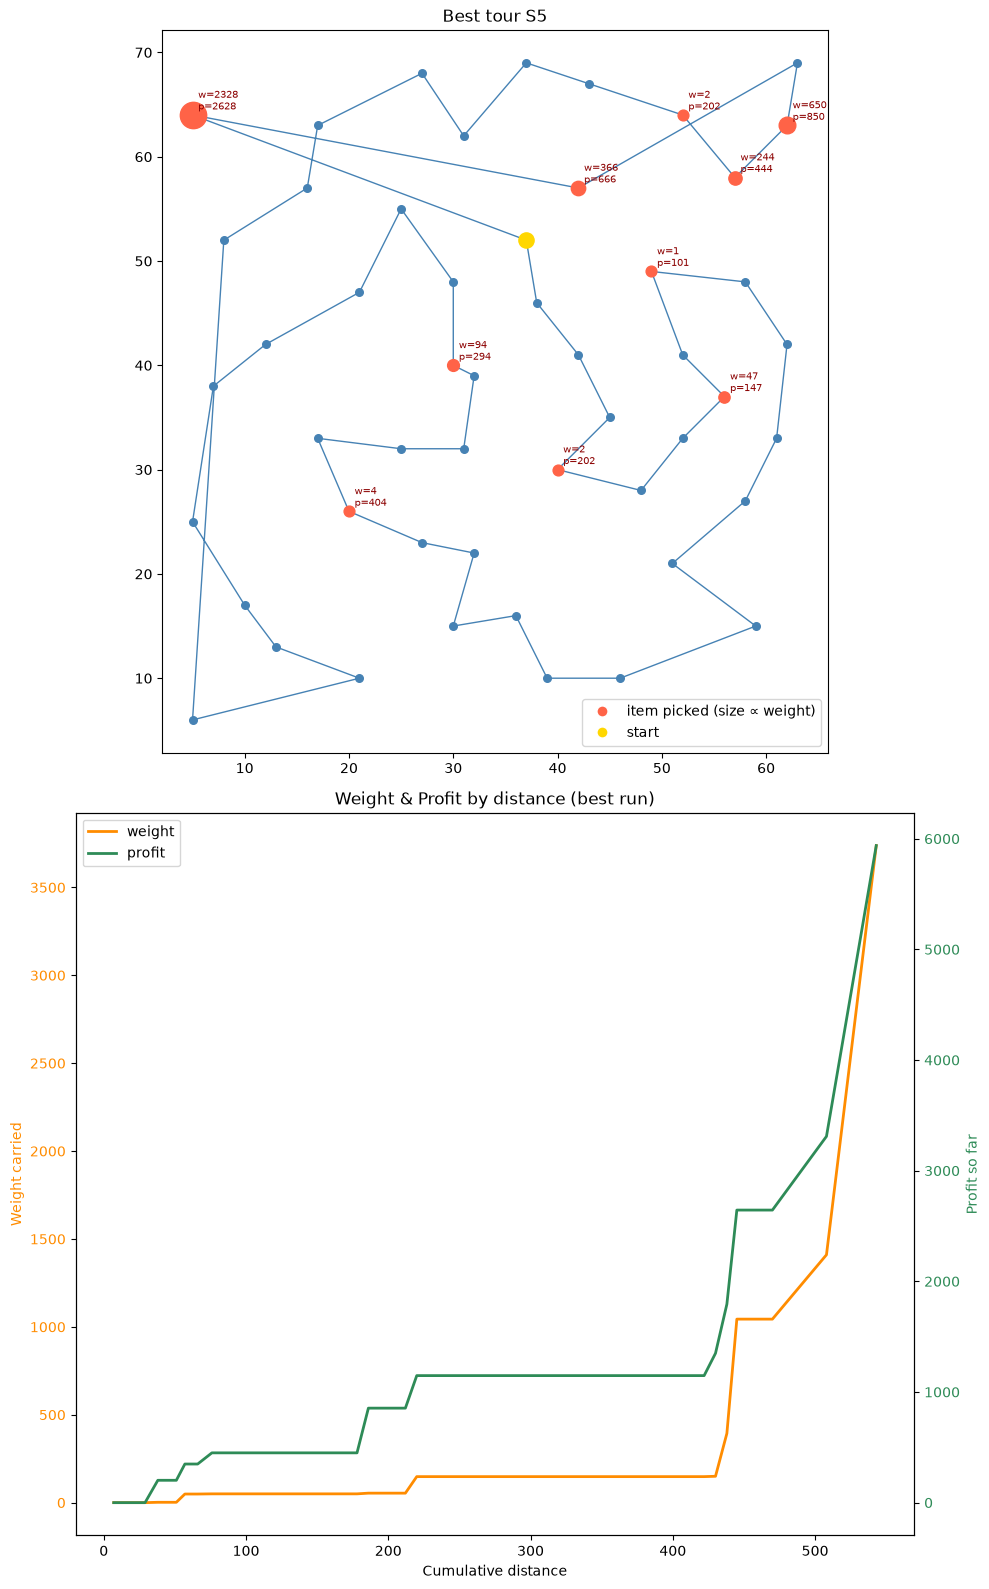

Animation saved to results/s5_weight_profit.gif


In [21]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [22]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,31,[],0.0,0.0,7,7.000000,-31.080000
1,31,10,[],0.0,0.0,7,7.000000,-62.160000
2,10,37,[],0.0,0.0,7,7.000000,-93.240000
3,37,4,[],0.0,0.0,8,8.000000,-128.760000
4,4,48,[3],2.0,202.0,9,9.004023,33.262139
5,48,8,[],2.0,202.0,7,7.003129,2.168248
6,8,49,[],2.0,202.0,6,6.002682,-24.483659
7,49,15,[48],49.0,349.0,6,6.066401,95.581522
8,15,1,[],49.0,349.0,9,9.099601,55.179294


## Brute Force

> **Warning:** exhaustive search over all `(n-1)! × 2^m` combinations. Only run on tiny toy instances (n ≤ 8, m ≤ 15).

In [23]:
if RUN_BRUTE_FORCE:
    bf_result = BruteForceSolver().solve(instance)
    all_results["Brute Force"] = [bf_result]
    display(results_summary([bf_result]))
    plot_convergence([bf_result], title=f"Brute Force — {INSTANCE_NAME}")
    plt.show()

In [24]:
if RUN_BRUTE_FORCE:
    fig, trace = plot_tour_with_weight_profit(instance, bf_result, "Brute Force")
    plt.show()

    anim = animate_weight_profit(instance, trace)
    anim.save("results/brute_force_weight_profit.gif", writer="pillow", fps=10)
    plt.close(anim._fig)
    print("Animation saved to results/brute_force_weight_profit.gif")

In [25]:
if RUN_BRUTE_FORCE:
    display(trace_to_dataframe(trace))

## Comparison

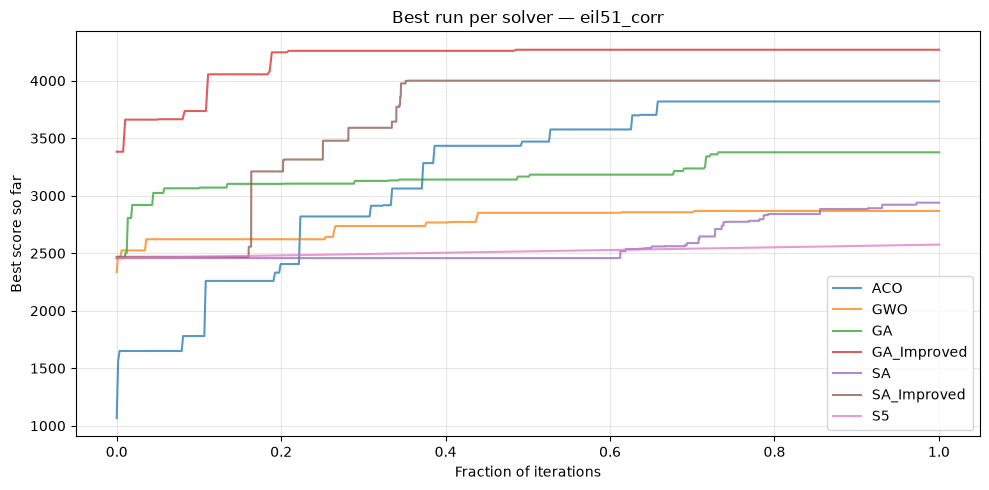

In [26]:
# convergence of all best runs overlaid (one line per algo)
best_per_algo = [max(rs, key=lambda r: r.convergence[-1]) for rs in all_results.values()]
plot_convergence(best_per_algo, title=f"Best run per solver — {INSTANCE_NAME}")
plt.show()

In [27]:
# scores and runtimes across all runs per solver
rows = []
for algo, rs in all_results.items():
    scores = [r.convergence[-1] for r in rs]
    runtimes = [r.runtime for r in rs]
    rows.append({
        "algo": algo,
        "best_score": max(scores),
        "mean_score": sum(scores) / len(scores),
        "worst_score": min(scores),
        "mean_runtime_s": sum(runtimes) / len(runtimes),
    })

pd.DataFrame(rows).set_index("algo").round(2)

,best_score,mean_score,worst_score,mean_runtime_s
algo,,,,
ACO,3819.45,3668.63,3582.68,10.07
GWO,2867.72,2775.44,2640.54,0.87
GA,3377.68,2954.05,2667.50,0.71
GA_Improved,4269.21,4008.98,3806.57,41.45
SA,2939.51,2845.65,2797.78,0.19
SA_Improved,4000.40,3891.81,3763.49,6.79
S5,2575.12,2575.12,2575.12,0.00
